# 🖼️ Part 3: Advanced Layouts – Subplots and Figures

In the previous notes, we created individual charts. However, professional data reports often require comparing multiple datasets side-by-side. This notebook covers the **Object-Oriented (OO) API** approach to creating complex grids.

### 🔑 The Core Concept: Figure vs. Axes
* **Figure**: The entire window or "canvas" that holds everything.
* **Axes (Ax)**: An individual plot within that figure. A figure can contain many axes.

---

## 🛠️ The `plt.subplots()` Command
Instead of using `plt.plot()`, we use `fig, ax = plt.subplots()`. This returns both the figure container and the specific plotting area (the axes).

### 📖 Key Arguments for `subplots()`
| Argument | Description | Values |
| :--- | :--- | :--- |
| **`nrows`** | Number of rows in the grid | Integer (e.g., `2`) |
| **`ncols`** | Number of columns in the grid | Integer (e.g., `2`) |
| **`figsize`** | Total width and height in inches | Tuple (e.g., `(10, 8)`) |
| **`sharex / sharey`** | Use the same axis scale for all plots | `True` or `False` |

In [2]:
import matplotlib.pyplot as plt
import numpy as np

## 📐 Step 1: Navigating the Grid

When you create a grid (like a $2 \times 2$ matrix), Matplotlib stores the axes in a NumPy array. You access them using index notation: `ax[row, col]`.

### 🛠️ Functions for Individual Axes
When using the OO API, the function names change slightly compared to the standard `plt` commands:

1.  **`ax.set_title()`**: Replaces `plt.title()`.
2.  **`ax.set_xlabel()` / `ax.set_ylabel()`**: Replaces `plt.xlabel()` and `plt.ylabel()`.
3.  **`ax.legend()`**: Works the same way but is applied specifically to that box.

---

### 💡 Why use the OO API?
It gives you much finer control. You can change the background color of just one specific plot or add different grid styles to the top-left vs. the bottom-right without them interfering with each other.

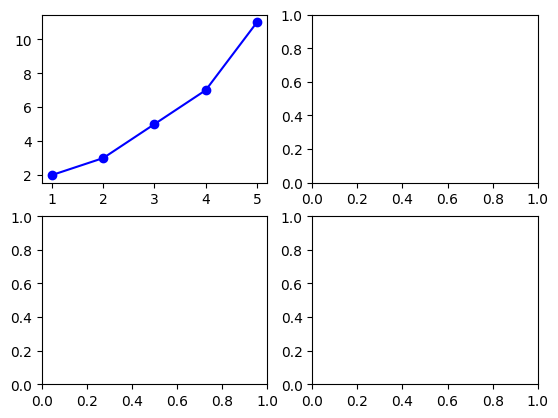

In [17]:
# Figure : Entire plotting area
# Ax: Each individual plot within the figure
x=np.array([1,2,3,4,5])
y=np.array([2,3,5,7,11])

figure, ax = plt.subplots(2,2)

ax[0,0].plot(x,y, label='Data Points', color='blue', linestyle='-', marker='o')

plt.show() # Display the figure with the subplot

## 🧪 Step 2: Creating the Dashboard

In this section, we combine different chart types (Line, Scatter, and Bar) into a single cohesive figure.

### 🛠️ Essential Layout Tuning
One common issue with subplots is that titles and labels often overlap. We solve this with:

#### 1. `plt.tight_layout()`
This automatically adjusts the padding between subplots so that everything fits perfectly without overlapping.

#### 2. `fig.suptitle()`
If you want one "Master Title" for the entire page (above all subplots), use `fig.suptitle('Global Title')`.

### 🎨 Customizing Specific Axes
As seen in the code, we can target specific indices:
* `ax[0, 0]`: Top-Left
* `ax[0, 1]`: Top-Right
* `ax[1, 0]`: Bottom-Left
* `ax[1, 1]`: Bottom-Right


---
> **💡 Pro-Tip:** If you only have one row of plots (e.g., `1x3`), you only need one index like `ax[0]`, `ax[1]`, `ax[2]`. The `[row, col]` format is only for 2D grids!

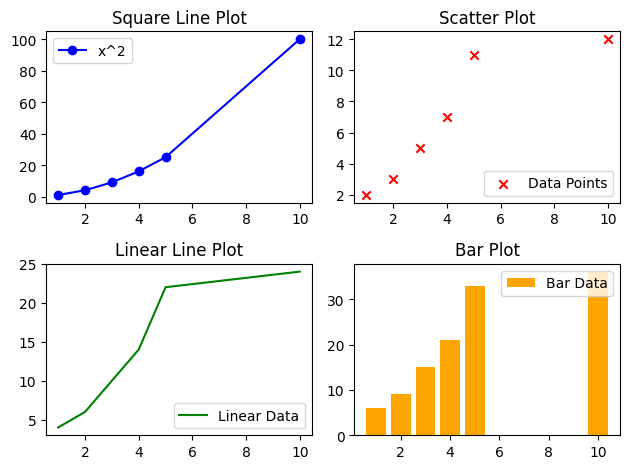

In [16]:
x=np.array([1,2,3,4,5,10])
y=np.array([2,3,5,7,11,12])

figure, ax = plt.subplots(2,2)

ax[0,0].plot(x,x**2, label='x^2', color='blue', linestyle='-', marker='o')
ax[0,0].title.set_text('Square Line Plot')
ax[0,0].legend()

ax[0,1].scatter(x,y, label='Data Points', color='red', marker='x')
ax[0,1].title.set_text('Scatter Plot')
ax[0,1].legend()

ax[1,0].plot(x,y*2, label='Linear Data', color='green')
ax[1,0].title.set_text('Linear Line Plot')
ax[1,0].legend()

ax[1,1].bar(x,y*3, label='Bar Data', color='orange')
ax[1,1].title.set_text('Bar Plot')
ax[1,1].legend()

plt.tight_layout() # Adjust layout to prevent overlap
plt.show() # Display the figure with the subplot

# 🧩 The Matplotlib "Split Personality": Pyplot vs. OO API

One of the most confusing things for beginners is that there are **two ways** to write Matplotlib code. Up until this point in our notes, we have been using the **Pyplot API**. Now, with subplots, we have moved to the **Object-Oriented (OO) API**.

---

## 1. The Pyplot API (What we used before)
**The Vibe:** "Quick and Dirty."
In our previous notebooks (Line, Bar, Pie charts), we used `plt.plot()`, `plt.title()`, and `plt.show()`. 

* **How it works:** It’s like a "state machine." Matplotlib keeps track of the "current" figure and axes. When you call `plt.title()`, it just adds a title to whatever is currently active.
* **The Problem:** If you want to manage 4 different plots at once (like in a dashboard), it becomes very hard to tell Matplotlib *which* plot you are talking to.

---

## 2. The Object-Oriented (OO) API (What we are using now)
**The Vibe:** "The Professional Developer way."
In this notebook, we started using `fig, ax = plt.subplots()`.

* **How it works:** We explicitly create **Objects**. 
    * `fig` (The Figure) is the entire window/canvas.
    * `ax` (The Axes) is a specific plotting area inside that window.
* **Why it's better:** We can talk to each "ax" by its name or index. Instead of saying "Put a title on the current plot," we say `ax[0, 1].set_title()`, which means "Put a title specifically on the top-right plot."



---

## 🔄 The "Syntax Translation" Cheat Sheet

When you switch to the OO API, some function names change slightly. This is usually where the confusion happens!

| Pyplot (Implicit) | OO API (Explicit) |
| :--- | :--- |
| `plt.plot()` | `ax.plot()` |
| `plt.title()` | `ax.set_title()` |
| `plt.xlabel()` | `ax.set_xlabel()` |
| `plt.ylabel()` | `ax.set_ylabel()` |
| `plt.xlim()` | `ax.set_set_xlim()` |
| `plt.grid()` | `ax.grid()` |

---

## 💡 Summary: When to use which?
* **Pyplot (`plt.something`)**: Use for quick data exploration or single, simple graphs.
* **OO API (`ax.set_something`)**: Use for complex layouts, subplots, or when building reusable visualization tools (like we are doing in this repo!).



---
### 🧪 Pro-Tip for your Code
In your latest code, you used `ax[0,0].set_text()`. While that works in some contexts, the standard OO way to add a heading to a subplot is **`ax[0,0].set_title('Your Title')`**. This keeps your code consistent with the official documentation!